# JetClass Substructure Visualization

This notebook loads the merged MiniJetClass dataset and visualizes jet
substructure observables across all 10 jet types.

In [1]:
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
import pathlib
import vector

vector.register_awkward()

%load_ext autoreload
%autoreload 2

%matplotlib inline
%config InlineBackend.figure_format='retina'

## Load the merged dataset

In [2]:
dataset_path = pathlib.Path("./data")
merged = ak.from_parquet(dataset_path / "MiniJetClass_merged.parquet")

jet_constituents = ak.zip(
    {
        "px": merged["part_px"],
        "py": merged["part_py"],
        "pz": merged["part_pz"],
        "E": merged["part_energy"],
    },
    with_name="Momentum4D",
)
jet_type_id = np.array(merged["jet_type_id"])
jet_type_names_all = np.array(merged["jet_type_name"])

# Build ordered list of unique jet type names (preserving id order)
jet_type_names = [
    jet_type_names_all[jet_type_id == i][0] for i in range(jet_type_id.max() + 1)
]

# Nice LaTeX-style labels for the 10 JetClass categories
JET_LABELS = {
    "ZJetsToNuNu": r"$q/g$",
    "HToBB": r"$H \to b\bar{b}$",
    "HToCC": r"$H \to c\bar{c}$",
    "HToGG": r"$H \to gg$",
    "HToWW4Q": r"$H \to WW^* \to 4q$",
    "HToWW2Q1L": r"$H \to WW^* \to 2q1\ell$",
    "ZToQQ": r"$Z \to q\bar{q}$",
    "WToQQ": r"$W \to q\bar{q}'$",
    "TTBar": r"$t\to bq\bar{q}'$",
    "TTBarLep": r"$t\to b\ell\nu$",
}

DEFAULT_COLORS = [
    # list of 10 colors based on table 1 in https://arxiv.org/pdf/2107.02270
    "#3f90da",  # blue
    "#bd1f01",  # red
    "#ffa90e",  # orange (yellow-ish)
    "#832db6",  # purple
    "#b9ac70",  # olive
    "#92dadd",  # light blue
    "#817175",  # grey (darker)
    "#a96b59",  # brown
    "#E76300",  # orange (red-ish)
    "#a4a294",  # grey
]

# set default colors for matplotlib plots
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=DEFAULT_COLORS)


def jet_label(name):
    """Return a nice label for a jet type name."""
    return JET_LABELS.get(name, name)


print(f"Loaded {len(jet_constituents)} jets")
for i, name in enumerate(jet_type_names):
    print(f"  {i}: {jet_label(name)}  ({np.sum(jet_type_id == i)} jets)")

Loaded 10000 jets
  0: $H \to b\bar{b}$  (1000 jets)
  1: $H \to c\bar{c}$  (1000 jets)
  2: $H \to gg$  (1000 jets)
  3: $H \to WW^* \to 2q1\ell$  (1000 jets)
  4: $H \to WW^* \to 4q$  (1000 jets)
  5: $t\to b\ell\nu$  (1000 jets)
  6: $t\to bq\bar{q}'$  (1000 jets)
  7: $W \to q\bar{q}'$  (1000 jets)
  8: $q/g$  (1000 jets)
  9: $Z \to q\bar{q}$  (1000 jets)


In [3]:
# remove constituents that are far away from the jet axis (deltaR > R)
R = 0.8

# Compute jet axis as the sum of all constituents
jet_axis = ak.sum(jet_constituents, axis=1)

# Compute deltaR of each constituent to the jet axis
# Broadcast jet_axis to match constituent shape
jet_axis_bcast = ak.unflatten(jet_axis, counts=1)
delta_r = jet_constituents.deltaR(jet_axis_bcast)

# Keep only constituents within R
mask = delta_r < R
jet_constituents_clean = jet_constituents[mask]

n_before = ak.sum(ak.num(jet_constituents))
n_after = ak.sum(ak.num(jet_constituents_clean))
print(f"Particles before cleaning: {n_before}")
print(f"Particles after cleaning:  {n_after}")
print(f"Removed: {n_before - n_after} ({(n_before - n_after) / n_before * 100:.2f}%)")

Particles before cleaning: 394954
Particles after cleaning:  393161
Removed: 1793 (0.45%)


## Compute jet substructure

Run the kt-based clustering and calculate N-subjettiness ($\tau_1$, $\tau_2$, $\tau_3$) and $D_2$ for all jets.

In [4]:
from jet_substructure import JetSubstructure

substructure = JetSubstructure(jet_constituents_clean, R=R)
sub = substructure.get_substructure_as_ak_array()

INFO:jet_substructure:Calculating substructure for 10000 jets
INFO:jet_substructure:Clustering jets with fastjet
INFO:jet_substructure:Jet definition: Longitudinally invariant kt algorithm with R = 0.8 and E scheme recombination


#--------------------------------------------------------------------------
#                         FastJet release 3.5.1


INFO:jet_substructure:Calculating N-subjettiness


#                 M. Cacciari, G.P. Salam and G. Soyez                  
#     A software package for jet finding and analysis at colliders      
#                           https://fastjet.fr                           
#	                                                                      
# Please cite EPJC72(2012)1896 [arXiv:1111.6097] if you use this package
# for scientific work and optionally PLB641(2006)57 [hep-ph/0512210].   
#                                                                       
# FastJet is provided without warranty under the GNU GPL v2 or higher.  
# It uses T. Chan's closest pair algorithm, S. Fortune's Voronoi code,
# CGAL and 3rd party plugin jet algorithms. See COPYING file for details.
#--------------------------------------------------------------------------


INFO:jet_substructure:Calculating D2


## Jet mass distributions

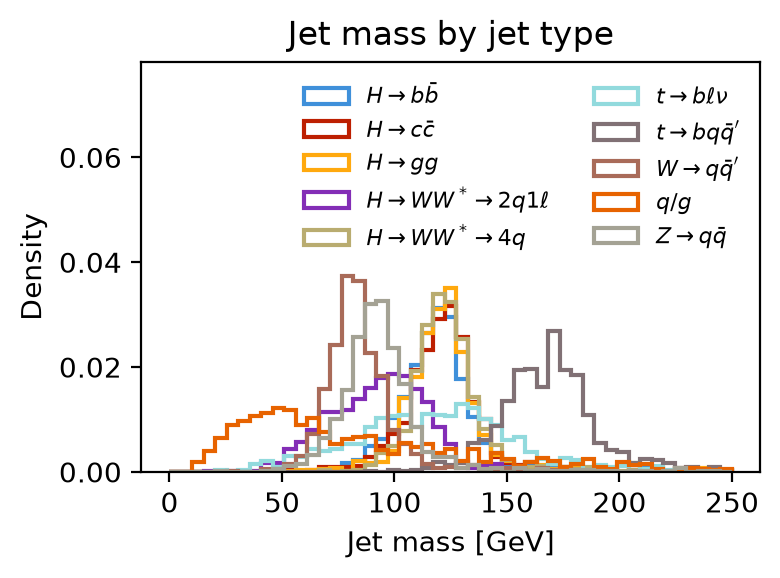

In [5]:
fig, ax = plt.subplots(figsize=(4, 3))
hist_kwargs = dict(
    bins=np.linspace(0, 250, 50), histtype="step", density=True, linewidth=1.5
)

for i, name in enumerate(jet_type_names):
    mask = jet_type_id == i
    ax.hist(np.array(sub["jet_mass"][mask]), **hist_kwargs, label=jet_label(name))

ax.set_xlabel("Jet mass [GeV]")
ax.set_ylabel("Density")
ax.legend(frameon=False, ncol=2, fontsize=8)
ax.set_title("Jet mass by jet type")

# increase ylim by factor of 1.8
ax.set_ylim(bottom=0, top=ax.get_ylim()[1] * 2.0)

plt.tight_layout()
plt.show()

## Subjettiness ratios

$\tau_{21} = \tau_2 / \tau_1$ probes 2-prong structure (e.g. $W/Z/H \to q\bar{q}$),
while $\tau_{32} = \tau_3 / \tau_2$ probes 3-prong structure (e.g. top quarks).

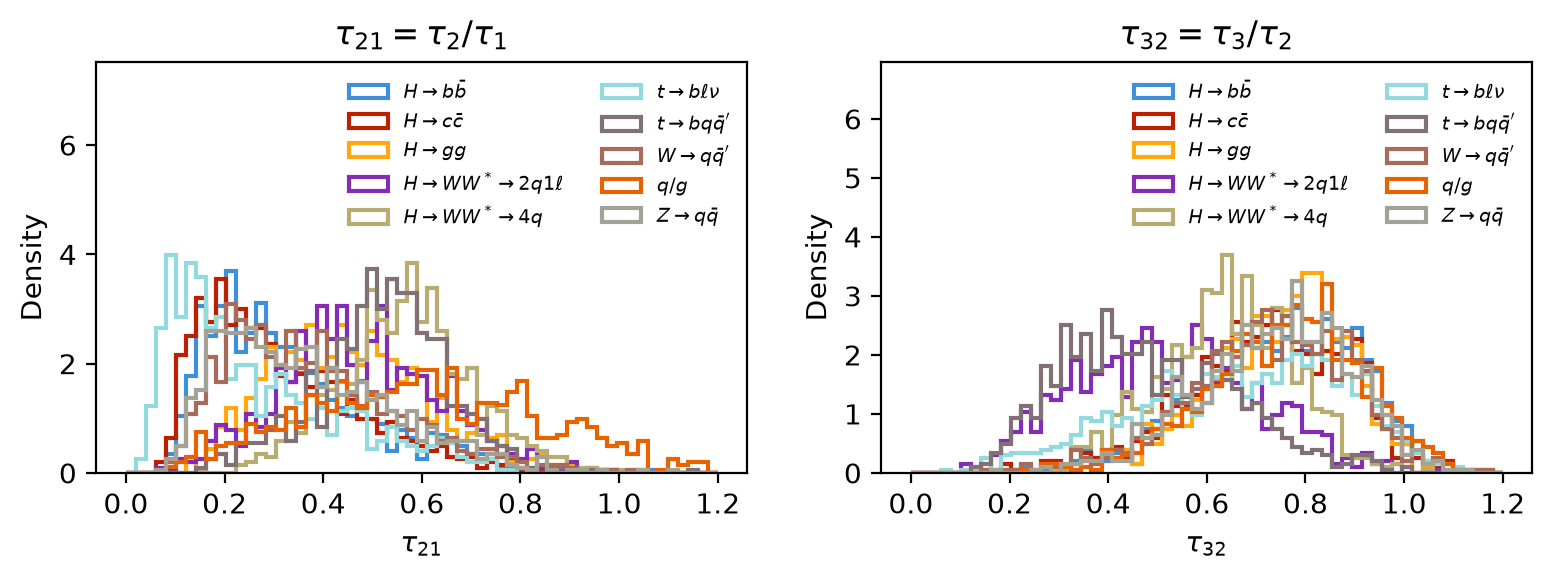

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
hist_kwargs = dict(
    bins=np.linspace(0, 1.2, 60), histtype="step", density=True, linewidth=1.5
)

for i, name in enumerate(jet_type_names):
    mask = jet_type_id == i
    label = jet_label(name)
    axes[0].hist(np.array(sub["tau21"][mask]), **hist_kwargs, label=label)
    axes[1].hist(np.array(sub["tau32"][mask]), **hist_kwargs, label=label)

axes[0].set_xlabel(r"$\tau_{21}$")
axes[0].set_ylabel("Density")
axes[0].set_title(r"$\tau_{21} = \tau_2 / \tau_1$")
axes[0].legend(frameon=False, ncol=2, fontsize=7)

axes[1].set_xlabel(r"$\tau_{32}$")
axes[1].set_ylabel("Density")
axes[1].set_title(r"$\tau_{32} = \tau_3 / \tau_2$")
axes[1].legend(frameon=False, ncol=2, fontsize=7)

# Increase ylim by factor of 1.8
axes[0].set_ylim(bottom=0, top=axes[0].get_ylim()[1] * 1.8)
axes[1].set_ylim(bottom=0, top=axes[1].get_ylim()[1] * 1.8)

plt.tight_layout()
plt.show()

## Subjettiness illustration

Visualize the $\tau_N$ calculation for one example jet per type. Each row shows a different jet type; columns show $N = 1, 2, 3$ subjets. 
Dots are constituents (sized by $p_T$, coloured by subjet assignment), crosses mark the subjet axes, and lines show the $\Delta R$ distances entering the $\tau_N$ sum.

In [7]:
def unwrap_phi(phi, phi_center):
    """Unwrap phi values relative to a center, avoiding 2pi jumps."""
    dphi = phi - phi_center
    dphi = (dphi + np.pi) % (2 * np.pi) - np.pi
    return phi_center + dphi


def plot_subjettiness_illustration(
    substructure, jet_idx, N=2, ax=None, title_prefix="", R=0.8
):
    data = substructure.get_subjettiness_illustration_data(jet_idx, N=N)
    constituents = data["constituents"]
    axes_data = data["subjet_axes"]
    assignment = data["subjet_assignment"]

    if ax is None:
        _, ax = plt.subplots(figsize=(4, 4))

    colors = [f"C{i}" for i in range(N)]

    # Jet axis = sum of all constituents
    jet_eta = float(substructure.jet_eta[jet_idx])
    jet_phi_raw = float(substructure.jet_phi[jet_idx])

    p_phi = unwrap_phi(constituents["phi"], jet_phi_raw)
    axes_phi = unwrap_phi(axes_data["phi"], jet_phi_raw)
    jet_phi = unwrap_phi(np.array([jet_phi_raw]), jet_phi_raw)[0]

    # Draw R circle centered on the jet axis
    circle = plt.Circle(
        (jet_eta, jet_phi),
        R,
        fill=False,
        linestyle="--",
        linewidth=1,
        color="grey",
        alpha=0.6,
        zorder=1,
    )
    ax.add_patch(circle)
    ax.set_aspect("equal")

    for i in range(N):
        mask = assignment == i
        ax.scatter(
            constituents["eta"][mask],
            p_phi[mask],
            s=constituents["pt"][mask] * 0.5,
            color=colors[i],
            alpha=0.6,
            zorder=3,
            label=f"Subjet {i + 1}",
        )

    for k in range(len(constituents["eta"])):
        i = assignment[k]
        ax.plot(
            [constituents["eta"][k], axes_data["eta"][i]],
            [p_phi[k], axes_phi[i]],
            color=colors[i],
            alpha=0.25,
            linewidth=0.8,
            zorder=2,
        )

    for i in range(N):
        ax.scatter(
            axes_data["eta"][i],
            axes_phi[i],
            marker="x",
            s=120,
            linewidths=2,
            color=colors[i],
            zorder=4,
        )

    tau_map = {1: substructure.tau1, 2: substructure.tau2, 3: substructure.tau3}
    tau_val = float(tau_map[N][jet_idx])
    prefix = f"{title_prefix} | " if title_prefix else ""
    ax.set_title(f"{prefix}$\\tau_{N}$ = {tau_val:.2f}", fontsize=10)
    ax.set_xlabel(r"$\eta$")
    ax.set_ylabel(r"$\phi$")

    return ax

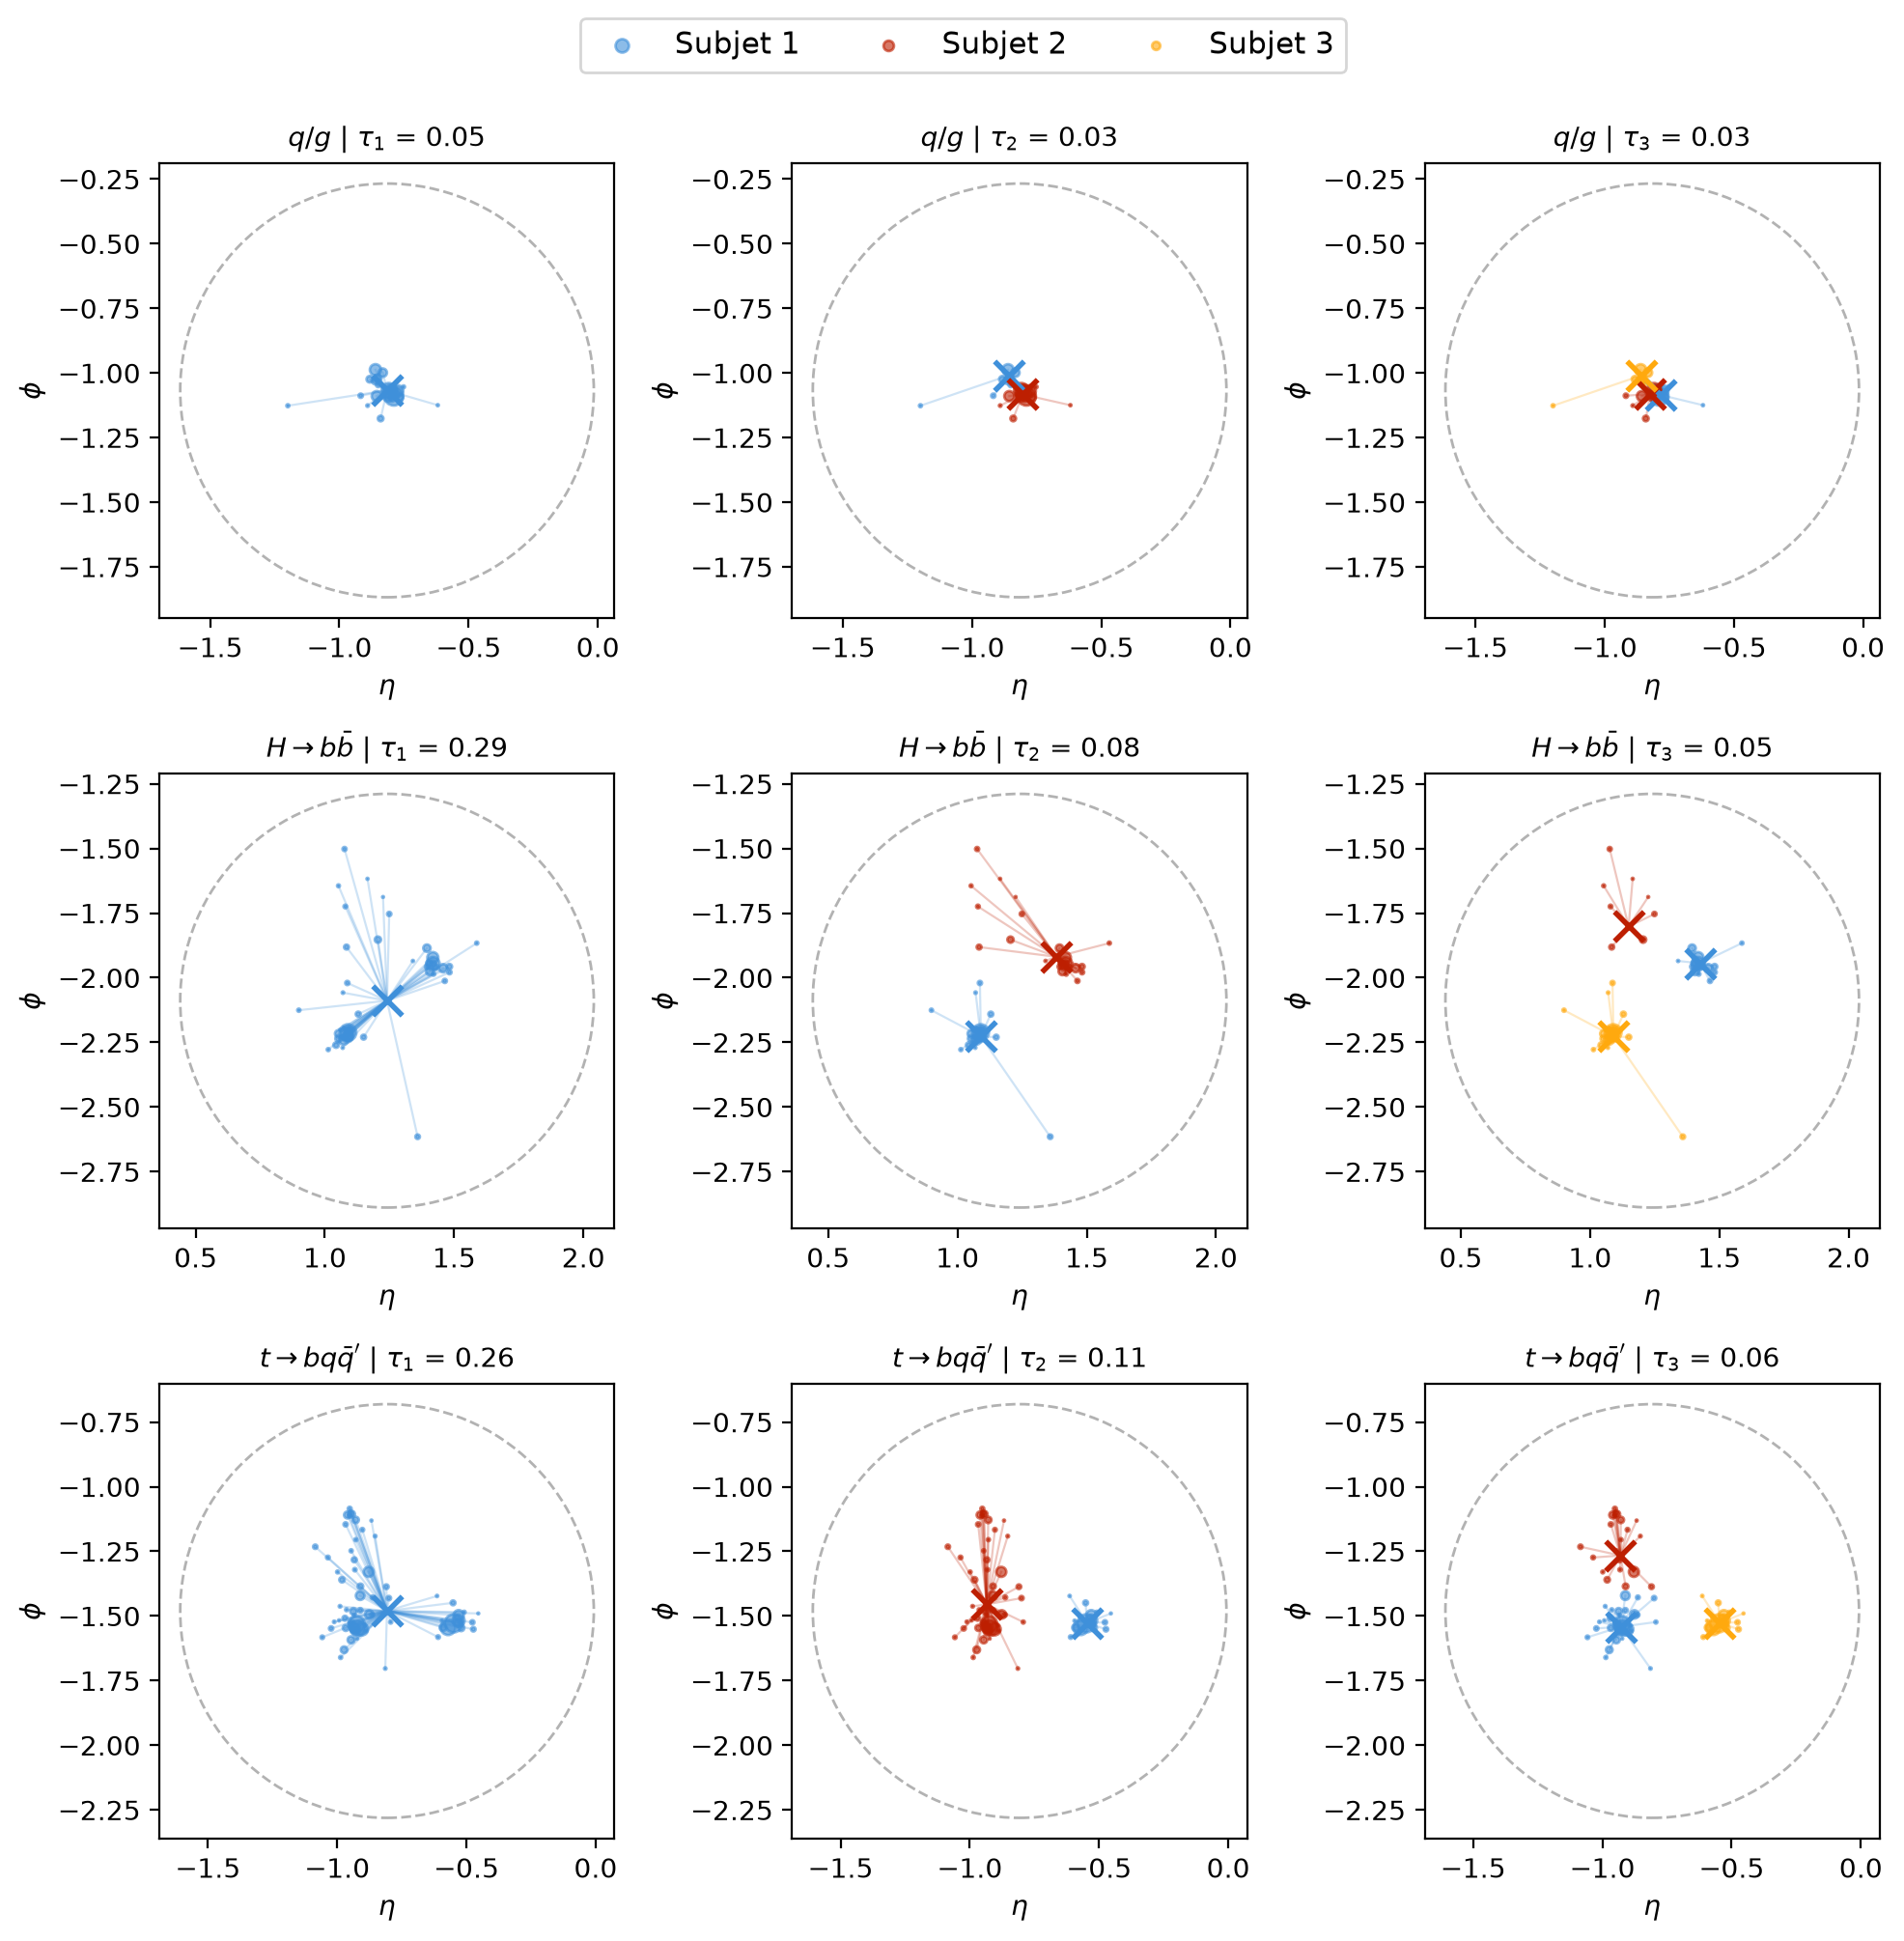

In [8]:
# Select which jet types to show (by name or index)
selected_types = [
    "ZJetsToNuNu",
    "HToBB",
    "TTBar",
    # "WToQQ",
]

selected_ids = [jet_type_names.index(name) for name in selected_types]
n_selected = len(selected_ids)

fig, axes = plt.subplots(n_selected, 3, figsize=(10, n_selected * 3.2))
if n_selected == 1:
    axes = axes[np.newaxis, :]

np.random.seed(50)
for row, type_id in enumerate(selected_ids):
    name = jet_type_names[type_id]
    indices = np.where(jet_type_id == type_id)[0]
    jet_idx = int(np.random.choice(indices))
    label = jet_label(name)

    for col, N in enumerate([1, 2, 3]):
        ax = axes[row, col]
        plot_subjettiness_illustration(
            substructure, jet_idx, N=N, ax=ax, title_prefix=label
        )

# Shared legend from the N=3 column
handles, labels = axes[0, -1].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    frameon=True,
    fontsize=11,
    bbox_to_anchor=(0.5, 1.05),
)
# fig.suptitle("Subjettiness illustration by jet type", fontsize=13, y=1.03)
fig.tight_layout()

pathlib.Path("assets").mkdir(parents=True, exist_ok=True)
fig.savefig("assets/subjettiness_illustration.pdf", bbox_inches="tight")
plt.show()